# DINOv2 Morphology Embeddings for Visium Spatial Transcriptomics

**Author: Mohamed Masoud**

This notebook demonstrates a foundation-model-inspired workflow for integrating tissue morphology with spatial transcriptomics.

[DINOv2](https://github.com/facebookresearch/dinov2) is a modern self-supervised Vision Transformer / vision foundation model available through Hugging Face Transformers. The demo extracts H&E image patches around Visium spots, compute [DINOv2](https://github.com/facebookresearch/dinov2) image embeddings, and compare morphology-based representations with transcriptomic Leiden clusters.


## Workflow

1. Clone `SpatialBio` and install dependencies.
2. Load processed Visium AnnData and H&E image.
3. Validate and select the correct image coordinate system.
4. Extract fixed-size 112 × 112 H&E patches around Visium spots.
5. Compute DINOv2 embeddings for all spots.
6. Smooth morphology embeddings using spatial neighbors.
7. Optimize smoothing strength, number of clusters, PCA dimension, and KMeans settings using ARI/NMI* against transcriptomic Leiden clusters.
8. Generate publication-style figures and save outputs.


*ARI measures exact cluster agreement, NMI measures shared information between
transcriptomic and morphology clusters. Higher values indicate stronger concordance.

# =========================
# Configuration
# =========================

MODEL_NAME = "dinov2"

PATCH_SIZE = 112

PCA_DIMS_GRID = [64, 96, 112, 128]

SMOOTH_K_GRID = [8, 12, 16]

N_CLUSTER_GRID = [6, 7, 8, 9, 10]

RANDOM_STATE = 42



---


## **Results**:

Best configuration:

- Patch size: 112
- PCA dimensions: 112
- Spatial smoothing k: 24
- Morphology clusters: 9

Metrics:

- ARI = 0.251
- NMI = 0.401



---



**Clone repo and install dependencies**

In [ ]:
!git clone https://github.com/Mmasoud1/SpatialBio.git
%cd SpatialBio

!pip install -q -r requirements.txt
!pip install -q transformers torch torchvision pillow tqdm umap-learn

Cloning into 'SpatialBio'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 54 (delta 11), reused 25 (delta 6), pack-reused 23 (from 1)
Receiving objects: 100% (54/54), 94.15 MiB | 13.34 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (11/11), done.
/content/SpatialBio
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17

**Imports**

In [ ]:
from pathlib import Path
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import scanpy as sc
import torch
from transformers import AutoImageProcessor, AutoModel

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
import umap


**Paths**

In [ ]:
ROOT = Path.cwd()

ZIP_PATH = ROOT / "data" / "raw" / "breast_visium.zip"
EXTRACT_DIR = ROOT / "data" / "extracted" / "visium_breast"
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "figures" / "foundation_models"

ADATA_PATH = PROCESSED_DIR / "adata_hvg.h5ad"
MORPH_EMB_PATH = PROCESSED_DIR / "dinov2_morphology_embeddings.npy"
MORPH_META_PATH = PROCESSED_DIR / "dinov2_morphology_metadata.csv"
MORPH_RESULTS_PATH = PROCESSED_DIR / "dinov2_morphology_parameter_search.csv"
MORPH_ADATA_PATH = PROCESSED_DIR / "adata_hvg_with_dinov2_morphology.h5ad"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("ZIP exists:", ZIP_PATH.exists())
print("AnnData exists:", ADATA_PATH.exists())


ZIP exists: True
AnnData exists: True


## Analysis configuration

The most important settings are `PATCH_SIZE = 112`, spatial smoothing with `SMOOTH_K_GRID`, and morphology cluster search with `N_CLUSTER_GRID`.


In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# DINOv2 model and patch extraction
MODEL_CHOICE = "dinov2"
MODEL_NAME = "facebook/dinov2-small"
PATCH_SIZE = 112
BATCH_SIZE = 32
MAX_SPOTS = None  # None = use all Visium spots.

# Embedding processing / optimization grid
PCA_COMPONENT_GRID = [50, 112]
SMOOTH_K_GRID = [0, 6, 12, 18, 24]  # 0 = no spatial smoothing
SMOOTH_ALPHA_GRID = [0.25, 0.50, 0.75, 1.00]  # 1.0 = fully smoothed neighbor-average embedding
N_CLUSTER_GRID = None  # None = test around transcriptomic Leiden cluster count.
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.20

print("Model:", MODEL_NAME)
print("Patch size:", PATCH_SIZE)
print("Batch size:", BATCH_SIZE)


Model: facebook/dinov2-small
Patch size: 112
Batch size: 32


**Extract dataset if needed**

In [ ]:
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

if ZIP_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print("Extracted to:", EXTRACT_DIR)
else:
    raise FileNotFoundError(f"Missing dataset zip: {ZIP_PATH}")

# Check extracted files
for p in list(EXTRACT_DIR.rglob("*"))[:30]:
    print(p)

Extracted to: /content/SpatialBio/data/extracted/visium_breast
/content/SpatialBio/data/extracted/visium_breast/breast
/content/SpatialBio/data/extracted/visium_breast/breast/filtered_feature_bc_matrix
/content/SpatialBio/data/extracted/visium_breast/breast/spatial
/content/SpatialBio/data/extracted/visium_breast/breast/filtered_feature_bc_matrix/barcodes.tsv.gz
/content/SpatialBio/data/extracted/visium_breast/breast/filtered_feature_bc_matrix/features.tsv.gz
/content/SpatialBio/data/extracted/visium_breast/breast/filtered_feature_bc_matrix/matrix.mtx.gz
/content/SpatialBio/data/extracted/visium_breast/breast/spatial/tissue_positions_list.csv
/content/SpatialBio/data/extracted/visium_breast/breast/spatial/aligned_fiducials.jpg
/content/SpatialBio/data/extracted/visium_breast/breast/spatial/tissue_lowres_image.png
/content/SpatialBio/data/extracted/visium_breast/breast/spatial/detected_tissue_image.jpg
/content/SpatialBio/data/extracted/visium_breast/breast/spatial/scalefactors_json.jso

**Load AnnData**

In [ ]:
adata = sc.read_h5ad(ADATA_PATH)

print(adata)
print("obs columns:", list(adata.obs.columns))
print("obsm keys:", list(adata.obsm.keys()))

if "spatial" not in adata.obsm:
    raise ValueError("Expected adata.obsm['spatial'] with Visium spot coordinates.")

if "leiden" not in adata.obs.columns:
    raise ValueError("Expected adata.obs['leiden'] from the transcriptomics workflow.")

AnnData object with n_obs × n_vars = 4869 × 2000
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'leiden', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'moranI', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'
obs columns: ['in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_co

**Find H&E image**

Searches inside extracted Visium files.

Image candidates:
/content/SpatialBio/data/extracted/visium_breast/breast/spatial/tissue_hires_image.png
Using image: /content/SpatialBio/data/extracted/visium_breast/breast/spatial/tissue_hires_image.png
Image size: (2000, 1335)


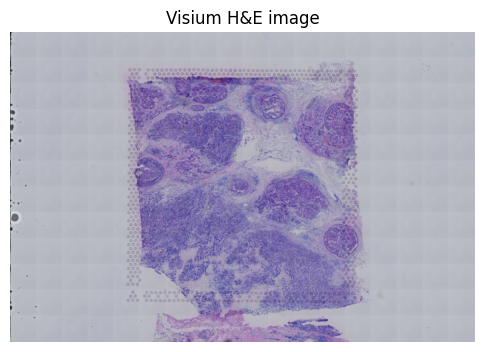

In [ ]:
image_candidates = list(EXTRACT_DIR.rglob("*tissue_hires_image*.png")) + \
                   list(EXTRACT_DIR.rglob("*tissue_hires_image*.jpg")) + \
                   list(EXTRACT_DIR.rglob("*tissue_hires_image*.jpeg"))

print("Image candidates:")
for p in image_candidates:
    print(p)

if len(image_candidates) == 0:
    raise FileNotFoundError("Could not find tissue_hires_image in extracted Visium data.")

image_path = image_candidates[0]
img = Image.open(image_path).convert("RGB")

print("Using image:", image_path)
print("Image size:", img.size)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Visium H&E image")
plt.show()

## Coordinate alignment check

This section tests coordinate mappings between Visium spot coordinates and the extracted `tissue_hires_image.png`.

The goal is to choose the coordinate system that best aligns spots with the H&E image before extracting DINOv2 morphology patches.

In [ ]:
import json
import pandas as pd

# Locate Visium spatial metadata
scale_candidates = list(EXTRACT_DIR.rglob("scalefactors_json.json"))
if len(scale_candidates) == 0:
    raise FileNotFoundError("Could not find scalefactors_json.json in extracted Visium data.")

scale_path = scale_candidates[0]

with open(scale_path, "r") as f:
    scalefactors = json.load(f)

hires_scale = scalefactors.get("tissue_hires_scalef", None)
spot_diameter_fullres = scalefactors.get("spot_diameter_fullres", None)

print("Using scalefactors:", scale_path)
print("scalefactors:", scalefactors)
print("hires_scale:", hires_scale)
print("spot_diameter_fullres:", spot_diameter_fullres)
print("H&E image size (width, height):", img.size)

Using scalefactors: /content/SpatialBio/data/extracted/visium_breast/breast/spatial/scalefactors_json.json
scalefactors: {'tissue_hires_scalef': 0.048109304, 'tissue_lowres_scalef': 0.014432792, 'fiducial_diameter_fullres': 285.1934000000001, 'spot_diameter_fullres': 176.54829999999995}
hires_scale: 0.048109304
spot_diameter_fullres: 176.54829999999995
H&E image size (width, height): (2000, 1335)


## Scale `adata.obsm["spatial"]` by `tissue_hires_scalef`

Tests the common Space Ranger case where AnnData stores full-resolution pixel coordinates, and the displayed image is downsampled to the hires image.

In [ ]:
if hires_scale is None:
    raise ValueError("Missing tissue_hires_scalef in scalefactors_json.json")

coords = adata.obsm["spatial"].copy() * hires_scale

print("Method coordinate range:")
print("x:", coords[:, 0].min(), coords[:, 0].max())
print("y:", coords[:, 1].min(), coords[:, 1].max())

Method coordinate range:
x: 582.651780744 1416.386019064
y: 223.70826359999998 1103.819870976


### Select coordinate method for patch extraction



In [ ]:
adata.obsm["spatial_hires"] = coords

print("Selected coordinate range:")
print("x:", coords[:, 0].min(), coords[:, 0].max())
print("y:", coords[:, 1].min(), coords[:, 1].max())
print("Image size:", img.size)
print("Fixed PATCH_SIZE:", PATCH_SIZE)

if spot_diameter_fullres is not None and hires_scale is not None:
    spot_diameter_hires = spot_diameter_fullres * hires_scale
else:
    spot_diameter_hires = None
print("spot_diameter_hires:", spot_diameter_hires)


Selected coordinate range:
x: 582.651780744 1416.386019064
y: 223.70826359999998 1103.819870976
Image size: (2000, 1335)
Fixed PATCH_SIZE: 112
spot_diameter_hires: 8.493615835383197


### Final visual check for selected coordinates

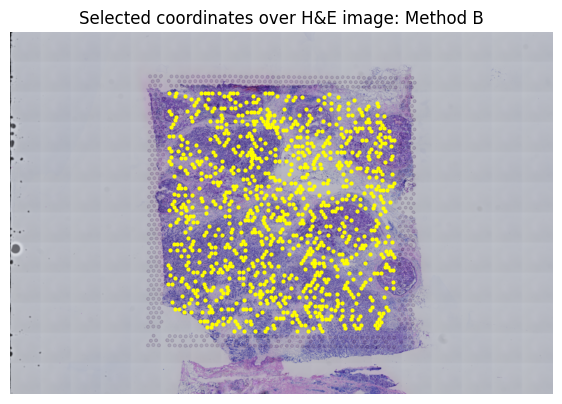

In [ ]:
sample_idx = np.random.choice(adata.n_obs, size=min(1000, adata.n_obs), replace=False)

plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.scatter(coords[sample_idx, 0], coords[sample_idx, 1], s=4, c="yellow")
plt.axis("off")
plt.title(f"Selected coordinates over H&E image: Method {COORD_METHOD}")
plt.show()

**Patch extraction function**

In [ ]:
def extract_patch(image, x, y, patch_size=PATCH_SIZE):
    """
    Extract square RGB patch centered at (x, y).
    Pads with white if patch extends outside image.
    """
    x = int(round(x))
    y = int(round(y))
    half = patch_size // 2

    w, h = image.size

    left = x - half
    upper = y - half
    right = x + half
    lower = y + half

    patch = Image.new("RGB", (patch_size, patch_size), color=(255, 255, 255))

    crop_left = max(left, 0)
    crop_upper = max(upper, 0)
    crop_right = min(right, w)
    crop_lower = min(lower, h)

    cropped = image.crop((crop_left, crop_upper, crop_right, crop_lower))

    paste_x = crop_left - left
    paste_y = crop_upper - upper

    patch.paste(cropped, (paste_x, paste_y))
    return patch

**Preview patches**

The image patches extracted around individual Visium spots before they are fed into DINOv2.

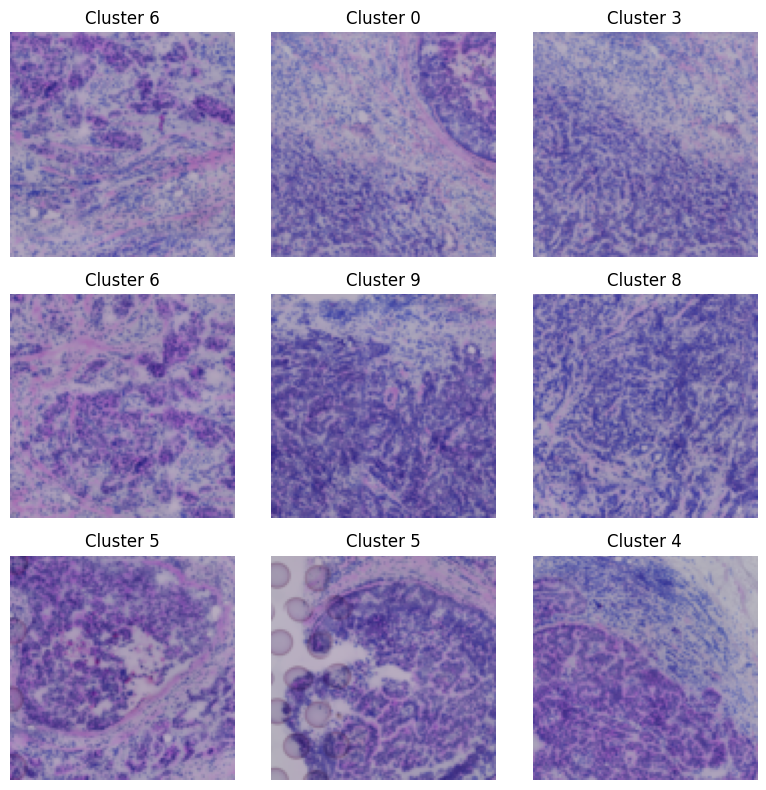

In [ ]:
preview_indices = np.random.choice(adata.n_obs, size=9, replace=False)

plt.figure(figsize=(8,8))
for i, idx in enumerate(preview_indices):
    x, y = coords[idx]
    patch = extract_patch(img, x, y, patch_size=PATCH_SIZE)
    ax = plt.subplot(3, 3, i+1)
    ax.imshow(patch)
    ax.set_title(f"Cluster {adata.obs['leiden'].iloc[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

These image patches are extracted around Visium spatial spots and serve as the input to DINOv2 for morphology embedding generation.

In [ ]:
print("Patch size:", PATCH_SIZE)
print("Number of spots:", adata.n_obs)
print("Embedding model: DINOv2")

Patch size: 112
Number of spots: 4869
Embedding model: DINOv2


**Load DINOv2**

Model selection is controlled by `MODEL_NAME` in the analysis configuration cell. Default is `facebook/dinov2-small` for Colab speed.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

print("Device:", device)
print("Model:", MODEL_NAME)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Device: cpu
Model: facebook/dinov2-small


In [ ]:
print("=" * 72)
print("DINOv2 Morphology Embedding Workflow")
print("=" * 72)
print(f"Patch size: {PATCH_SIZE} x {PATCH_SIZE} pixels")
print(f"Number of Visium spots: {adata.n_obs:,}")
print(f"Embedding model: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Coordinate method: {COORD_METHOD}")
print(f"PCA grid: {PCA_COMPONENT_GRID}")
print(f"Smoothing k grid: {SMOOTH_K_GRID}")
print(f"Smoothing alpha grid: {SMOOTH_ALPHA_GRID}")
print("Transcriptomic Leiden clusters:", adata.obs["leiden"].nunique())
print("=" * 72)


DINOv2 Morphology Embedding Workflow
Patch size: 112 x 112 pixels
Number of Visium spots: 4,869
Embedding model: facebook/dinov2-small
Device: cpu
Coordinate method: B
PCA grid: [50, 112]
Smoothing k grid: [0, 6, 12, 18, 24]
Smoothing alpha grid: [0.25, 0.5, 0.75, 1.0]
Transcriptomic Leiden clusters: 12


**Compute DINOv2 embeddings**

`MAX_SPOTS = None` uses all Visium spots. For quick debugging, set `MAX_SPOTS = 1000` in the configuration cell.


In [ ]:
n_spots = adata.n_obs if MAX_SPOTS is None else min(int(MAX_SPOTS), adata.n_obs)
selected_idx = np.arange(n_spots)

all_embeddings = []

with torch.no_grad():
    for start in tqdm(range(0, n_spots, BATCH_SIZE)):
        batch_idx = selected_idx[start:start + BATCH_SIZE]

        patches = [
            extract_patch(img, coords[i, 0], coords[i, 1], patch_size=PATCH_SIZE)
            for i in batch_idx
        ]

        inputs = processor(images=patches, return_tensors="pt").to(device)
        outputs = model(**inputs)

        # CLS token embedding: one vector per Visium spot
        emb = outputs.last_hidden_state[:, 0, :].detach().cpu().numpy()
        all_embeddings.append(emb)

morph_embeddings = np.vstack(all_embeddings)

print("Selected spots:", n_spots)
print("Embeddings shape:", morph_embeddings.shape)


  0%|          | 0/153 [00:00<?, ?it/s]

Selected spots: 4869
Embeddings shape: (4869, 384)


## Smooth and optimize morphology clustering

This block searches multiple spatial smoothing strengths, PCA dimensions, and cluster numbers. It keeps the best setting by ARI first and NMI second. `smooth_k = 0` is the no-smoothing baseline.


In [ ]:
adata_sub = adata[selected_idx].copy()
adata_sub.obsm["X_dinov2_morphology"] = morph_embeddings
coords_sub = coords[selected_idx]

true_labels = adata_sub.obs["leiden"].astype(str).values
n_transcriptomic_clusters = adata_sub.obs["leiden"].nunique()

if N_CLUSTER_GRID is None:
    low = max(2, n_transcriptomic_clusters - 3)
    high = n_transcriptomic_clusters + 4
    N_CLUSTER_GRID = list(range(low, high))

print(adata_sub)
print("Stored:", "X_dinov2_morphology" in adata_sub.obsm)
print("Transcriptomic clusters:", n_transcriptomic_clusters)
print("Morphology cluster grid:", N_CLUSTER_GRID)


AnnData object with n_obs × n_vars = 4869 × 2000
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'leiden', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'moranI', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_hires', 'X_dinov2_morphology'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'
Stored: True
Transcriptomic clusters: 12
M

In [ ]:
def spatially_smooth_embeddings(X, coords_xy, k=12, alpha=1.0):
    """Return spatially smoothed embeddings using k nearest Visium spots.

    k=0 returns the original embeddings.
    alpha controls the blend between original and neighbor-averaged embeddings:
      0.0 = original embeddings only
      1.0 = fully smoothed neighbor-average embeddings
    """
    if k is None or k <= 0 or alpha <= 0:
        return X.copy()

    k_eff = min(int(k) + 1, X.shape[0])  # +1 includes self
    nbrs = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
    nbrs.fit(coords_xy)
    _, indices = nbrs.kneighbors(coords_xy)

    X_neighbors = np.stack([X[idx].mean(axis=0) for idx in indices], axis=0)
    return (1.0 - alpha) * X + alpha * X_neighbors


def cluster_and_score(X_input, n_pca, smooth_k, smooth_alpha, n_clusters):
    X_scaled = StandardScaler().fit_transform(X_input)
    n_pca_eff = min(int(n_pca), X_scaled.shape[1], X_scaled.shape[0] - 1)
    X_pca_tmp = PCA(n_components=n_pca_eff, random_state=RANDOM_STATE).fit_transform(X_scaled)

    labels = KMeans(
        n_clusters=int(n_clusters),
        random_state=RANDOM_STATE,
        n_init=20
    ).fit_predict(X_pca_tmp).astype(str)

    ari_tmp = adjusted_rand_score(true_labels, labels)
    nmi_tmp = normalized_mutual_info_score(true_labels, labels)

    return X_pca_tmp, labels, ari_tmp, nmi_tmp


In [ ]:
results = []
best = None

for smooth_k in SMOOTH_K_GRID:
    alpha_values = [0.0] if smooth_k == 0 else SMOOTH_ALPHA_GRID
    for smooth_alpha in alpha_values:
        X_smooth = spatially_smooth_embeddings(
            morph_embeddings,
            coords_sub,
            k=smooth_k,
            alpha=smooth_alpha
        )

        for n_pca in PCA_COMPONENT_GRID:
            for n_clusters in N_CLUSTER_GRID:
                X_pca_tmp, labels_tmp, ari_tmp, nmi_tmp = cluster_and_score(
                    X_smooth,
                    n_pca=n_pca,
                    smooth_k=smooth_k,
                    smooth_alpha=smooth_alpha,
                    n_clusters=n_clusters
                )

                row = {
                    "smooth_k": smooth_k,
                    "smooth_alpha": smooth_alpha,
                    "pca_components": min(int(n_pca), X_smooth.shape[1], X_smooth.shape[0] - 1),
                    "n_clusters": int(n_clusters),
                    "ARI": ari_tmp,
                    "NMI": nmi_tmp,
                }
                results.append(row)

                if best is None or (ari_tmp, nmi_tmp) > (best["ARI"], best["NMI"]):
                    best = row | {
                        "X_smooth": X_smooth,
                        "X_pca": X_pca_tmp,
                        "labels": labels_tmp,
                    }

results_df = pd.DataFrame(results).sort_values(["ARI", "NMI"], ascending=False).reset_index(drop=True)
results_df.to_csv(MORPH_RESULTS_PATH, index=False)

best_ari = best["ARI"]
best_nmi = best["NMI"]
best_smooth_k = best["smooth_k"]
best_smooth_alpha = best["smooth_alpha"]
best_n_clusters = best["n_clusters"]
best_pca_components = best["pca_components"]
X_morph_smooth = best["X_smooth"]
X_pca = best["X_pca"]
morph_clusters = best["labels"]

cluster_col = "dinov2_morphology_cluster_optimized"
adata_sub.obsm["X_dinov2_morphology_smoothed"] = X_morph_smooth
adata_sub.obsm["X_dinov2_morphology_pca"] = X_pca
adata_sub.obs[cluster_col] = morph_clusters.astype(str)

print("Best morphology setting")
print("-----------------------")
print(f"smooth_k      : {best_smooth_k}")
print(f"smooth_alpha  : {best_smooth_alpha}")
print(f"PCA components: {best_pca_components}")
print(f"n_clusters    : {best_n_clusters}")
print(f"ARI           : {best_ari:.4f}")
print(f"NMI           : {best_nmi:.4f}")

results_df.head(10)


Best morphology setting
-----------------------
smooth_k      : 24
smooth_alpha  : 1.0
PCA components: 112
n_clusters    : 9
ARI           : 0.2515
NMI           : 0.4010


,smooth_k,smooth_alpha,pca_components,n_clusters,ARI,NMI
0,24,1.00,112,9,0.251471,0.401000
1,18,1.00,112,9,0.243607,0.391468
2,24,1.00,50,9,0.236477,0.387779
3,24,0.75,50,13,0.236431,0.411880
4,18,0.75,50,9,0.235379,0.378595
5,18,1.00,50,9,0.234866,0.380516
6,24,1.00,50,12,0.234861,0.398505
7,12,1.00,112,9,0.233697,0.377399
8,24,1.00,112,11,0.232581,0.400825
9,24,1.00,50,14,0.232330,0.411310


## UMAP visualization of optimized DINOv2 morphology embeddings

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


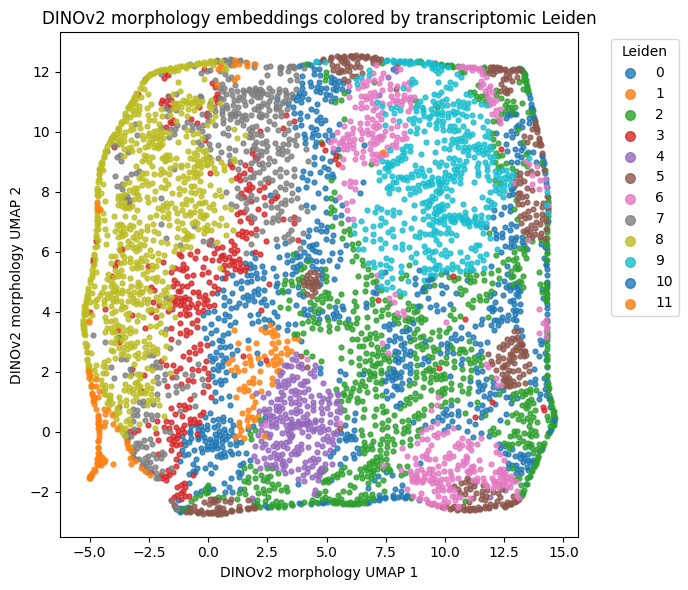

In [ ]:
reducer = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=RANDOM_STATE
)

X_umap_morph = reducer.fit_transform(X_pca)
adata_sub.obsm["X_umap_dinov2_morphology"] = X_umap_morph

plot_df = pd.DataFrame({
    "UMAP1": X_umap_morph[:, 0],
    "UMAP2": X_umap_morph[:, 1],
    "leiden": adata_sub.obs["leiden"].astype(str).values,
    "morphology_cluster": adata_sub.obs[cluster_col].astype(str).values,
})

plt.figure(figsize=(7, 6))
for cluster in sorted(plot_df["leiden"].unique(), key=lambda x: int(x) if str(x).isdigit() else str(x)):
    d = plot_df[plot_df["leiden"] == cluster]
    plt.scatter(d["UMAP1"], d["UMAP2"], s=12, label=cluster, alpha=0.8)

plt.xlabel("DINOv2 morphology UMAP 1")
plt.ylabel("DINOv2 morphology UMAP 2")
plt.title("DINOv2 morphology embeddings colored by transcriptomic Leiden")
plt.legend(title="Leiden", bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "dinov2_morphology_umap_by_transcriptomic_leiden.png", dpi=300, bbox_inches="tight")
plt.show()


DINOv2 morphology embedding space colored using the transcriptomic Leiden labels. Several large regions dominated by a single transcriptomic cluster as shown. That means DINOv2 embeddings are capturing biologically meaningful structure.

## Spatial comparison figure




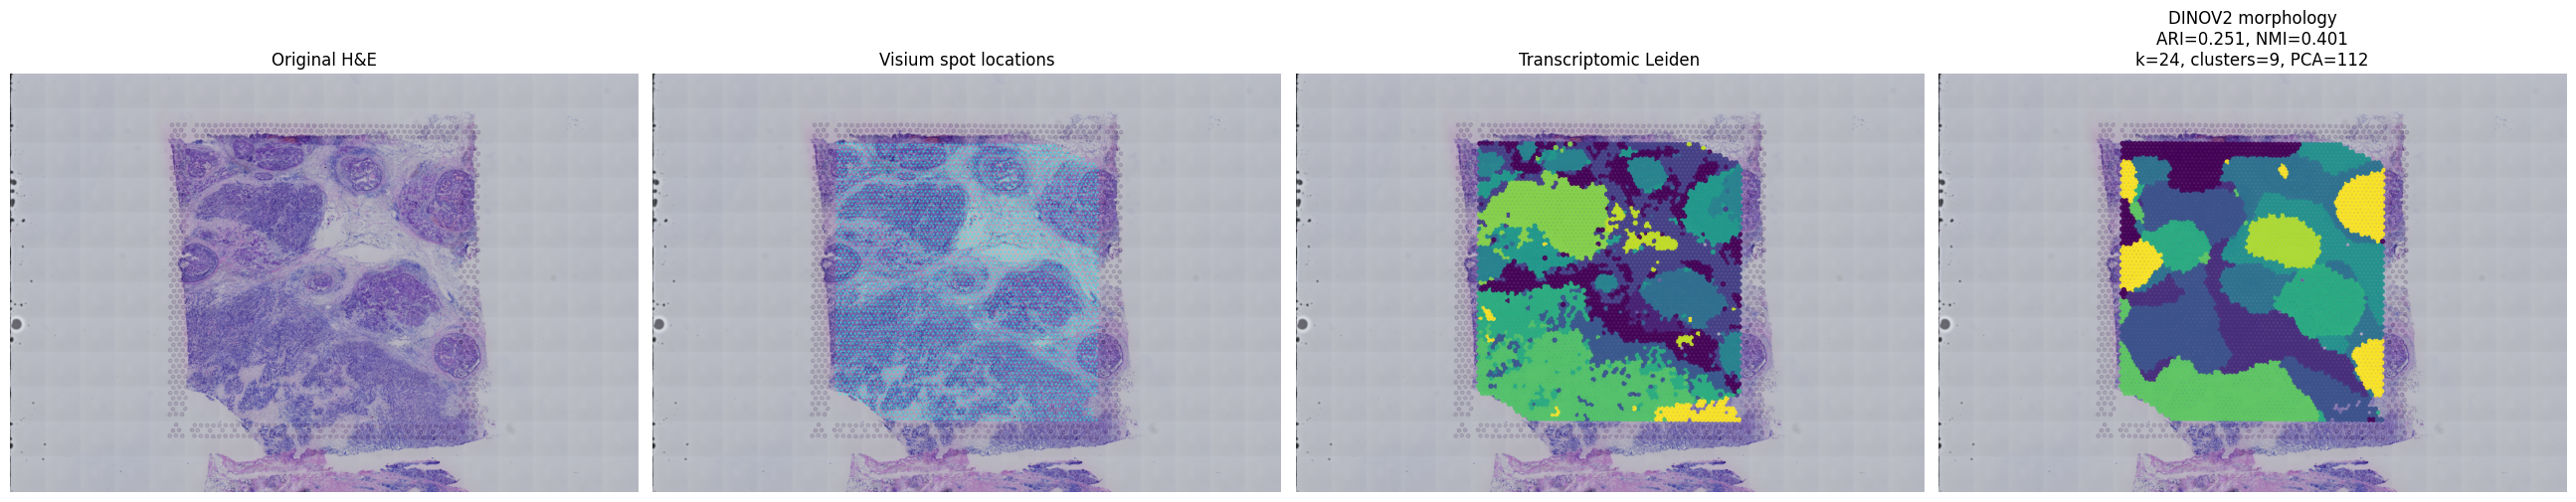

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(26, 6))

# Original H&E
axes[0].imshow(img)
axes[0].set_title("Original H&E")
axes[0].axis("off")

# Visium spots
axes[1].imshow(img)
axes[1].scatter(
    coords_sub[:, 0],
    coords_sub[:, 1],
    s=0.5,
    c="cyan",
    alpha=0.4
)
axes[1].set_title("Visium spot locations")
axes[1].axis("off")

# Transcriptomic Leiden clusters
axes[2].imshow(img)
axes[2].scatter(
    coords_sub[:, 0],
    coords_sub[:, 1],
    c=pd.Categorical(adata_sub.obs["leiden"]).codes,
    s=8,
    alpha=0.85
)
axes[2].set_title("Transcriptomic Leiden")
axes[2].axis("off")

# Optimized morphology clusters
axes[3].imshow(img)
axes[3].scatter(
    coords_sub[:, 0],
    coords_sub[:, 1],
    c=pd.Categorical(adata_sub.obs[cluster_col]).codes,
    s=8,
    alpha=0.85
)
axes[3].set_title(
    f"{MODEL_CHOICE.upper()} morphology\n"
    f"ARI={best_ari:.3f}, NMI={best_nmi:.3f}\n"
    f"k={best_smooth_k}, clusters={best_n_clusters}, PCA={best_pca_components}"
)
axes[3].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "dinov2_spatial_morphology_vs_transcriptomics.png", dpi=300, bbox_inches="tight")
plt.show()


The morphology clusters are: Spatially coherent,  large contiguous tissue regions, respect major histological structures, not random salt-and-pepper noise

The graph smoothing clearly helped better clustering and the DINOv2 morphology map (right) looks biologically informative.

## Cross-tab morphology vs transcriptomics

In [ ]:
ct = pd.crosstab(
    adata_sub.obs["leiden"],
    adata_sub.obs[cluster_col],
    normalize="index"
)

ct


dinov2_morphology_cluster_optimized,0,1,2,3,4,5,6,7,8
leiden,,,,,,,,,
0,0.111258,0.225166,0.038411,0.388079,0.147020,0.029139,0.001325,0.006623,0.052980
1,0.000000,0.236111,0.000000,0.083333,0.000000,0.680556,0.000000,0.000000,0.000000
2,0.111650,0.014563,0.008495,0.254854,0.382282,0.036408,0.001214,0.154126,0.036408
3,0.006116,0.602446,0.217125,0.033639,0.012232,0.003058,0.091743,0.003058,0.030581
4,0.008439,0.004219,0.000000,0.029536,0.008439,0.936709,0.000000,0.000000,0.012658
5,0.205882,0.000000,0.000000,0.283422,0.000000,0.008021,0.002674,0.000000,0.500000
6,0.053050,0.013263,0.023873,0.180371,0.055703,0.270557,0.013263,0.021220,0.368700
7,0.007009,0.261682,0.607477,0.004673,0.000000,0.000000,0.112150,0.000000,0.007009
8,0.000000,0.047254,0.291188,0.000000,0.000000,0.000000,0.661558,0.000000,0.000000


Rows = transcriptomic Leiden clusters (0–11)

Columns = DINOv2 morphology clusters (0–8)

Several Leiden clusters map very strongly to a single morphology cluster:

Leiden	|  Best morphology cluster	 |   Fraction

4	      |           5	               |    0.937

**Save outputs**

In [ ]:
np.save(MORPH_EMB_PATH, morph_embeddings)

metadata_cols = ["leiden", cluster_col]
metadata = adata_sub.obs[metadata_cols].copy()
metadata["spot_id"] = adata_sub.obs_names
metadata["coord_x_hires"] = coords_sub[:, 0]
metadata["coord_y_hires"] = coords_sub[:, 1]
metadata["best_smooth_k"] = best_smooth_k
metadata["best_smooth_alpha"] = best_smooth_alpha
metadata["best_n_clusters"] = best_n_clusters
metadata["best_pca_components"] = best_pca_components
metadata["best_ari"] = best_ari
metadata["best_nmi"] = best_nmi
metadata.to_csv(MORPH_META_PATH, index=False)

adata_sub.uns["dinov2_morphology_best_params"] = {
    "model_name": MODEL_NAME,
    "patch_size": PATCH_SIZE,
    "smooth_k": int(best_smooth_k),
    "smooth_alpha": float(best_smooth_alpha),
    "n_clusters": int(best_n_clusters),
    "pca_components": int(best_pca_components),
    "ARI": float(best_ari),
    "NMI": float(best_nmi),
}
adata_sub.write_h5ad(MORPH_ADATA_PATH)

print("Saved:")
print(MORPH_EMB_PATH)
print(MORPH_META_PATH)
print(MORPH_RESULTS_PATH)
print(MORPH_ADATA_PATH)
print(FIG_DIR / "dinov2_morphology_umap_by_transcriptomic_leiden.png")
print(FIG_DIR / "dinov2_spatial_morphology_vs_transcriptomics.png")


## Conclusion

This notebook demonstrates a morphology–transcriptomics integration workflow for 10x Visium data.

DINOv2 extracts morphology embeddings from fixed 112 × 112 H&E patches centered on Visium spots. The embeddings are then optionally smoothed over a spatial neighbor graph and clustered. A small parameter search evaluates smoothing strength, PCA dimensionality, and morphology cluster count using ARI/NMI against transcriptomic Leiden clusters.

The optimized outputs are stored in AnnData under:

- `adata_sub.obsm["X_dinov2_morphology"]`
- `adata_sub.obsm["X_dinov2_morphology_smoothed"]`
- `adata_sub.obsm["X_dinov2_morphology_pca"]`
- `adata_sub.obsm["X_umap_dinov2_morphology"]`
- `adata_sub.obs["dinov2_morphology_cluster_optimized"]`

This workflow can be extended to pathology-specific foundation models such as UNI, Virchow, or CONCH for stronger histopathology-aware representations.


## Future Directions

- Compare DINOv2 with pathology foundation models:
  - PLIP
  - UNI
  - Virchow
  - CONCH
  

- Evaluate additional tissues and Visium datasets.

- Investigate graph neural network smoothing.